In [1]:
from ete4 import PhyloTree
from ete4.smartview import Layout, BASIC_LAYOUT, TextFace

#tree = PhyloTree("/home/izirdeli/Documents.cglab/OLFACTION/phylo_trees/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.clustalo.gt01.lg.fasttree.nw")
#tree = PhyloTree("../data/ReferenceTree/PF13853.060925_DeepTax.clustalo.gt01.lg.fasttree", parser=1)
#tree = PhyloTree("../data/ReferenceTree/PF13853.060925_DeepTax.clustalo.gt01.treefile", parser=1)
tree = PhyloTree("../data/ReferenceTree/PF13853.060925_DeepTax.einsi.gt01.treefile", parser=1)
#tree = PhyloTree("../data/ReferenceTree/PF00001.060925_DeepTax_localfasta_9606_7897_7918_7955_34765_7739_51511_7719_137246_75743_7868_7741_7764_7740_7227_6087.clustalo.gt01.lg.fasttree")
#tree = PhyloTree("/home/izirdeli/Documents.cglab/Projects/ASR/all_species_asr/PF13853.9606_7955_7740_7764_75743_137246.clustalo.gt01.lg.fasttree.withinternalnames.nw", parser=1)

midp = tree.get_midpoint_outgroup()
tree.set_outgroup(midp)

### color branches
taxid_color_map = {
    "9606": "#b97171",     
    "7955": "#2A9D8F",     
    "7740": "#C4A01D",     
    "7764": "#6A4C93",      
    "75743": "#C56E4F",     
    "137246": "#C56E4F",
    "7897": "#886f7a",
    "7918": "#566573",
    "34765": "#c290a6",
    "7739": "#ad3f71",
    "51511": "#cc8265",
    "7719": "#3b6387",
    "7868": "#d415ba",
    "7741": "#0092b3"     
}

# GROUP_COLORS = {
#     "Human (class 1)":      "#7f1734",
#     "Human (class 2)":      "#557c99",
#     "Human (unclassified)": "#b97171",   # falls back to the original Human colour (unused: all 433 classified)
#     "Zebrafish":            "#2A9D8F",
#     "Amphioxus":            "#C4A01D",
#     "Hagfish":              "#6A4C93",
#     "Catshark":             "#C56E4F",
#     "Bambooshark":          "#C56E4F",
# }



# taxid_color_map = {
#     "9606": "#b97171",     
#     "7955": "#2A9D8F",     
#     "7740": "#F4D35E",     
#     "7764": "#F4D35E",      
#     "75743": "#49ff33",     
#     "137246": "#49ff33",
#     "7897": "#b97171",
#     "7918": "#2A9D8F",
#     "34765": "#c290a6",
#     "7739": "#F4D35E",
#     "51511": "#cc8265",
#     "7719": "#3b6387",
#     "7868": "#49ff33",
#     "7741": "#F4D35E"     
# }

for node in tree.traverse():
    if node.is_leaf:
        taxid = node.name.split('.')[0]
        node.props['taxid'] = taxid

branch_styles = {}
for node in tree.traverse():
    if node.is_leaf and 'taxid' in node.props:
        taxid = node.props['taxid']
        if taxid in taxid_color_map:
            color = taxid_color_map[taxid]
            branch_styles[node] = {'stroke-width': 2.8, 'stroke': color}

def draw_taxid_colored_branches(node):
    style = branch_styles.get(node, None)
    return {'hz-line': style, 'vt-line': style} if style else {}

layout = Layout(name="TaxID Branch Coloring", draw_node=draw_taxid_colored_branches)

### visualizing
tree.explore(layouts=[layout, BASIC_LAYOUT])


Explorer now available at http://127.0.0.1:5002


In [4]:
from ete4 import PhyloTree
from ete4.smartview import Layout, BASIC_LAYOUT

#tree = PhyloTree("/home/izirdeli/Documents.cglab/OLFACTION/phylo_trees/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.clustalo.gt01.lg.fasttree.nw")
tree = PhyloTree("../data/ReferenceTree/PF13853.060925_DeepTax.einsi.gt01.treefile", parser=1)


# midpoint root
midp = tree.get_midpoint_outgroup()
tree.set_outgroup(midp)

taxid_color_map = {
    "9606": "#b97171",     
    "7955": "#2A9D8F",     
    "7740": "#C4A01D",     
    "7764": "#6A4C93",      
    "75743": "#C56E4F",     
    "137246": "#C56E4F",
    "7897": "#886f7a",
    "7918": "#566573",
    "34765": "#c290a6",
    "7739": "#ad3f71",
    "51511": "#cc8265",
    "7719": "#3b6387",
    "7868": "#d415ba",
    "7741": "#0092b3"     
}

# 1. annotate leaves with taxid
for node in tree.traverse():
    if node.is_leaf:
        taxid = node.name.split('.')[0]
        node.props['taxid'] = taxid

# 2. collect leaves manually (no get_leaves / iter_leaves)
leaves = [n for n in tree.traverse() if n.is_leaf]

# 3. branch style map:
#    key = node
#    value = dict with stroke info for the incoming branch leading to that node
branch_styles = {}

for leaf in leaves:
    taxid = leaf.props.get('taxid', None)
    if taxid is None:
        continue
    color = taxid_color_map.get(taxid, None)
    if color is None:
        continue

    # walk from this leaf up toward the root
    curr = leaf
    while curr is not None:
        # assign style for the branch that leads to `curr`
        if curr not in branch_styles:
            branch_styles[curr] = {
                'stroke-width': 2.8,
                'stroke': color
            }
        curr = curr.up  # climb one ancestor up


# 4. layout callback: tell smartview how to draw each node's incoming edge
def draw_taxid_colored_branches(node):
    style = branch_styles.get(node, None)
    # ETE4 smartview uses 'hz-line' and 'vt-line' style dicts per node.
    # return both so horizontal + vertical segments get colored.
    return {'hz-line': style, 'vt-line': style} if style else {}

layout = Layout(
    name="TaxID Branch Coloring (full path)",
    draw_node=draw_taxid_colored_branches
)

tree.explore(
    layouts=[layout, BASIC_LAYOUT],
    popup_prop_keys=["name", "taxid", "dist", "support"]
)


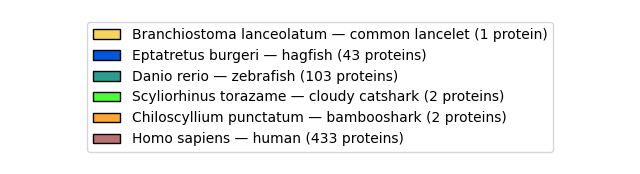

In [11]:
# legend for the six species
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

species_info = [
    ("Branchiostoma lanceolatum — common lancelet (1 protein)", "#F4D35E"),
    ("Eptatretus burgeri — hagfish (43 proteins)", "#0057da"),
    ("Danio rerio — zebrafish (103 proteins)", "#2A9D8F"),
    ("Scyliorhinus torazame — cloudy catshark (2 proteins)", "#49ff33"),
    ("Chiloscyllium punctatum — bambooshark (2 proteins)", "#FFA630"),
    ("Homo sapiens — human (433 proteins)", "#b97171")
]

# Build legend handles
handles = [Patch(facecolor=hex_color, edgecolor='black', label=label) 
           for label, hex_color in species_info]

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
legend = ax.legend(handles=handles, loc='center', ncol=1, frameon=True)#, title="Species Legend")
# Save
out_path_png = "../figures/six_species_legend.png"
plt.savefig(out_path_png, bbox_inches='tight', dpi=300)
#plt.show()